# That fancy figure 

Six exemplary connectomes, selected from different extrema in the landscape. 

Further versions of this file aer saved in the "scripts" folder, but start with "X_" to make them not pollute GIT unnecessarily.

In [1]:
# experiment_name = "76_90000_samples_animal_206"  # MaMI 
# dataset_name = "suarez_MaMI_dataset"

# experiment_name =  "04_big_overnight_run"  # Humans
# dataset_name = "hcp_schaefer_100_dataset" 

dataset_name = "hcp_schaefer_100_dataset" # lexis_data" # "suarez_MaMI_dataset"
experiment_name = "105_distance_metrics_mst_animal_0" # 05_mst_animal_0" # 02_ring_sweeps_animal_0" # 05_mst_animal_0" # 


# experiment_name =  "05_mst_animal_0"  # Humans
# # experiment_name = "03_no_ring_sweeps_animal_0"
# # experiment_name = "02_ring_sweeps_animal_0"  
# dataset_name = "lexis_data"

draft_mode = False # True


margin_x = 0.5
margin_y = 0.05
# interesting_eta_and_gamma_combinations = [ # for MaMI 
#     [-8+margin_x, 1-margin_y],  
#     [3-margin_x, 1-margin_y], 
#     [-0.8, 0.18],
#     [3-margin_x, -0.1+margin_y], 
#     [-8+margin_x, -0.1+margin_y],
#     [-3.65, 0.15],
#     [-5, 0.5],
# ]

# interesting_eta_and_gamma_combinations = [ # for Humans 
#     [-8+margin_x, 1-margin_y],  
#     [3-margin_x, 1-margin_y], 
#     [-3.2, 0.55],
#     [3-margin_x, -0.1+margin_y], 
#     [-8+margin_x, -0.1+margin_y],
#     # [-5, 0.5],
#     [-3.2, 0.18],
# ]


# interesting_eta_and_gamma_combinations = [ # for Lexis: MST 
#     [-8+margin_x, 1-margin_y],  
#     [3-margin_x, 1-margin_y], 
#     [1, 0.4],
#     [3-margin_x, -0.1+margin_y], 
#     [-8+margin_x, -0.1+margin_y],
#     [-3.65, 0.15],
#     # [-5, 0.5],
# ]


interesting_eta_and_gamma_combinations = [ # for HCP: MST
    [-8+margin_x, 1-margin_y],  
    [3-margin_x, 1-margin_y], 
    [-0.5, 0.25], # [0.9, 0.35],
    [3-margin_x, -0.1+margin_y], 
    [-8+margin_x, -0.1+margin_y],
    [-3.6, 0.1], # 3.75 # 
    # [-5, 0.5],
]


In [2]:
from notebook_setup import setup
from vizman import viz
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

from matplotlib import font_manager
for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

from kaysons_visual_config import * # Kayson's file. 

from src.visualization.find_and_plot_closest_connectome import find_closest_connectome, plot_connectome_blockwise, compare_orderings

env = setup()

Enabled autoreload.
Current path is: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/scripts


In [3]:
base_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm") / dataset_name / experiment_name

data_dir = base_path / "generated_networks"
# save_dir = base_path / "generated_networks_visualizations"
save_dir = base_path / "landscape_and_six_example_gen_connectomes"
save_dir.mkdir(parents=True, exist_ok=True)

# Choose clustering method: 'spectral', 'hierarchical', 'modularity', 'degree', or None
clustering_method = 'spectral'

# Store connectomes and parameters
connectomes = []
params = []

for parameter_combination in interesting_eta_and_gamma_combinations:
    target_eta = parameter_combination[0]
    target_gamma = parameter_combination[1]
    
    found_eta, found_gamma, connectome = find_closest_connectome(target_eta, target_gamma, data_dir)
    
    connectomes.append(connectome)
    params.append((found_eta, found_gamma))
    
    parameter_combination.append(found_eta)
    parameter_combination.append(found_gamma)


Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/generated_networks
Found 1 closest file(s)
Target (η, γ): (-7.5, 0.95)
Closest file found: net_eta-7.551020622253418_gamma0.955102026462554_ruleMatchingIndex_id008.npy
Found  (η, γ): (-7.551, 0.955)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/generated_networks
Found 1 closest file(s)
Target (η, γ): (2.5, 0.95)
Closest file found: net_eta2.551020383834839_gamma0.955102026462554_ruleMatchingIndex_id004.npy
Found  (η, γ): (2.551, 0.955)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/generated_networks
Found 1 closest file(s)
Target (η, γ): (-0.5, 0.25)
Closest file found: net_eta-0.59183669090271_gamma0.259183675050735_ruleMatchingIndex_id006.npy
Fou

In [4]:
# Load the metrics data
# metrics_csv_path = base_path / f"all_metrics_for_{experiment_name}.csv"
metrics_csv_path = base_path / f"summary_indiv_energy_for_exp_{experiment_name}.csv"
gnm_results_df = pd.read_csv(metrics_csv_path, index_col=False)

# Prepare data for MaxCriteria metric
df = gnm_results_df.copy()
df["eta"] = pd.to_numeric(df["eta"], errors='coerce')
df["gamma"] = pd.to_numeric(df["gamma"], errors='coerce')

# Find the MaxCriteria column
metric_col_name = next(col for col in df.columns if "MaxCrit_subject_0" in col)
df[metric_col_name] = pd.to_numeric(df[metric_col_name], errors='coerce')
df = df.dropna(subset=['eta', 'gamma', metric_col_name])


# BINNING
BINNING = False 
if BINNING: 
    # bin the eta and gamma values into 100 bins each
    df['eta'] = pd.cut(df['eta'], bins=100)
    df['gamma'] = pd.cut(df['gamma'], bins=100)

# PIVOTING
# Pivot the DataFrame to create a matrix for heatmap
heatmap_data = df.pivot_table(index='gamma', columns='eta', values=metric_col_name)

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/landscape_and_six_example_gen_connectomes/figure_1_landscape_and_connectomes_105_distance_metrics_mst_animal_0.pdf


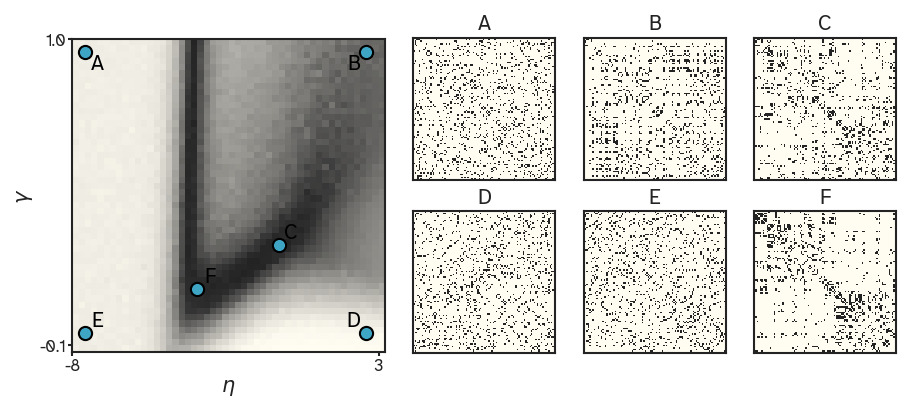

In [5]:
point_color = "#E84653" # LECKER RED
point_color = "#3FA5C4" #44cfcf" # #394D73" # #0F14F7" # TEAL or so
 
fig, axes = plt.subplot_mosaic(
    [["landscape", "landscape", "A", "B", "C"], 
     ["landscape", "landscape", "D", "E", "F"]], 
    figsize=(viz.cm_to_inch((18, 7))), dpi=150
    
)

# Flip the heatmap data vertically
heatmap_data_flipped = heatmap_data.iloc[::-1]

sns.heatmap(
    heatmap_data_flipped,
    square=True,    
    xticklabels=False, 
    yticklabels=False,  
    cbar=False, # True, # False,
    cmap=default_cmaps["hb_bw"],
    ax=axes["landscape"]
)

eta_values = heatmap_data_flipped.columns # np.array([interval.mid for interval in heatmap_data_flipped.columns])
gamma_values = heatmap_data_flipped.index # np.array([interval.mid for interval in heatmap_data_flipped.index])

# Set x-axis ticks (η) - only first and last
eta_min, eta_max = eta_values.min(), eta_values.max()
x_tick_positions = [0, len(eta_values) - 1]  # First and last positions
x_tick_labels = [f"{eta_min:.1f}" if eta_min % 1 != 0 else f"{int(eta_min)}", 
                 f"{eta_max:.1f}" if eta_max % 1 != 0 else f"{int(eta_max)}"]
axes["landscape"].set_xticks(x_tick_positions)
axes["landscape"].set_xticklabels(x_tick_labels)

# Set y-axis ticks (γ) - only first and last
gamma_min, gamma_max = gamma_values.min(), gamma_values.max()
y_tick_positions = [0, len(gamma_values) - 1]  # First and last positions
y_tick_labels = [f"{gamma_max:.1f}", f"{gamma_min:.1f}"]  # Note: reversed because data is flipped
axes["landscape"].set_yticks(y_tick_positions)
axes["landscape"].set_yticklabels(y_tick_labels, rotation=0)

# Set axis labels
axes["landscape"].set_xlabel(r"$\eta$") 
axes["landscape"].set_ylabel(r"$\gamma$") 

# Flip the y-axis to have low gamma at bottom
eta_values = heatmap_data_flipped.columns
gamma_values = heatmap_data_flipped.index

scatter_x = []
scatter_y = []

for combo in interesting_eta_and_gamma_combinations:
    target_eta = combo[0]
    target_gamma = combo[1]
    
    # Find closest indices in the heatmap
    x_idx = np.argmin(np.abs(eta_values - target_eta))
    y_idx = np.argmin(np.abs(gamma_values - target_gamma))
    
    scatter_x.append(x_idx)
    scatter_y.append(y_idx)

# Add scatter points to the landscape
axes["landscape"].scatter(
    scatter_x,
    scatter_y,
    color=point_color,
    s=40,
    edgecolors='black',
    linewidths=1.0,
    zorder=10,  # Ensure points are on top
    label='Selected Networks'
)

# Add text next to each point
labels = ['A', 'B', 'C', 'D', 'E', 'F']

############# FINETUNING THE SHIFTS #############
right = int(14 / 300 * len(eta_values)) # should work perfectly for 300x300 heatmap, but maybe not for smaller / bigger ones...
left = int(14 / 300 * len(eta_values))
up = int(14 / 300 * len(eta_values))
down = int(14 / 300 * len(eta_values))

shifts = {
    'A': (right, down),
    'B': (-left, down),
    'C': (right, -up),
    'D': (-left, -up),
    'E': (right, -up),
    'F': (right, -up),
}

label_background_size = 2
for x, y, label in zip(scatter_x, scatter_y, labels):
    shift_x, shift_y = shifts[label]
    # Add white background for text
    ax = axes["landscape"]
    # ax.add_patch(plt.Rectangle((x+shift_x-label_background_size, y+shift_y-label_background_size - 0.15), 
    #                              2*label_background_size, 2*label_background_size, color='white', alpha=0.4, edgecolor='none', linewidth=0)) # , zorder=5))
    color = "black" 
    # if label == "C": 
    #     color = "white" 
    ax.text(x+shift_x, y+shift_y, f'{label}', 
            color=color, ha="center", va="center")


# Plot connectomes
for idx, ax_label in enumerate(["A", "B", "C", "D", "E", "F"]):
    sns.heatmap(
        connectomes[idx],
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
        cmap=default_cmaps["bw_hb"],
        ax=axes[ax_label]
    )
    found_eta, found_gamma = params[idx][0], params[idx][1]
    axes[ax_label].set_title(ax_label)
        # r"$\eta$: " + f"{np.round(found_eta)}," + r"$\gamma$: " + f"{np.round(found_gamma)}")  
        
sns.despine(fig=fig, top=False, right=False, left=False, bottom=False)
#plt.tight_layout()

if draft_mode:
    save_path = save_dir / f"figure_1_landscape_and_connectomes_draft_{experiment_name}.pdf"
    # Add title with offset
    plt.subplots_adjust(top=0.84)
    plt.suptitle(f"Draft Figure 1: {dataset_name}, {experiment_name}") # fontsize=16)
else:
    save_path = save_dir / f"figure_1_landscape_and_connectomes_{experiment_name}.pdf"
    
    
plt.savefig(save_path, bbox_inches="tight")
print(save_path)

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/landscape_and_six_example_gen_connectomes/figure_1_ONLY_landscape_105_distance_metrics_mst_animal_0.pdf


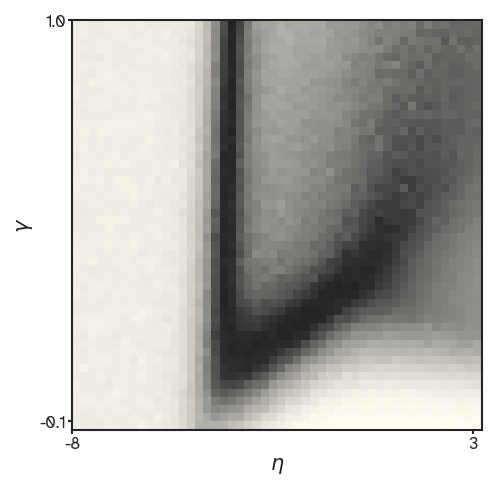

In [25]:
point_color = "#E84653" # LECKER RED
point_color = "#3FA5C4" #44cfcf" # #394D73" # #0F14F7" # TEAL or so
 
# fig, axes = plt.subplot_mosaic(
#     [["landscape", "landscape", "A", "B", "C"], 
#      ["landscape", "landscape", "D", "E", "F"]], 
#     figsize=(viz.cm_to_inch((18, 7))), dpi=150
    
# )

fig, axes = plt.subplot_mosaic(
    [["landscape"]], 
    figsize=(viz.cm_to_inch((9,9))), dpi=150
    
)

# Flip the heatmap data vertically
heatmap_data_flipped = heatmap_data.iloc[::-1]

sns.heatmap(
    heatmap_data_flipped,
    square=True,    
    xticklabels=False, 
    yticklabels=False,  
    cbar=False, # True, # False,
    cmap=default_cmaps["hb_bw"],
    ax=axes["landscape"]
)

eta_values = heatmap_data_flipped.columns # np.array([interval.mid for interval in heatmap_data_flipped.columns])
gamma_values = heatmap_data_flipped.index # np.array([interval.mid for interval in heatmap_data_flipped.index])

# Set x-axis ticks (η) - only first and last
eta_min, eta_max = eta_values.min(), eta_values.max()
x_tick_positions = [0, len(eta_values) - 1]  # First and last positions
x_tick_labels = [f"{eta_min:.1f}" if eta_min % 1 != 0 else f"{int(eta_min)}", 
                 f"{eta_max:.1f}" if eta_max % 1 != 0 else f"{int(eta_max)}"]
axes["landscape"].set_xticks(x_tick_positions)
axes["landscape"].set_xticklabels(x_tick_labels)

# Set y-axis ticks (γ) - only first and last
gamma_min, gamma_max = gamma_values.min(), gamma_values.max()
y_tick_positions = [0, len(gamma_values) - 1]  # First and last positions
y_tick_labels = [f"{gamma_max:.1f}", f"{gamma_min:.1f}"]  # Note: reversed because data is flipped
axes["landscape"].set_yticks(y_tick_positions)
axes["landscape"].set_yticklabels(y_tick_labels, rotation=0)

# Set axis labels
axes["landscape"].set_xlabel(r"$\eta$") 
axes["landscape"].set_ylabel(r"$\gamma$") 

# Flip the y-axis to have low gamma at bottom
eta_values = heatmap_data_flipped.columns
gamma_values = heatmap_data_flipped.index

scatter_x = []
scatter_y = []

for combo in interesting_eta_and_gamma_combinations:
    target_eta = combo[0]
    target_gamma = combo[1]
    
    # Find closest indices in the heatmap
    x_idx = np.argmin(np.abs(eta_values - target_eta))
    y_idx = np.argmin(np.abs(gamma_values - target_gamma))
    
    scatter_x.append(x_idx)
    scatter_y.append(y_idx)

# # Add scatter points to the landscape
# axes["landscape"].scatter(
#     scatter_x,
#     scatter_y,
#     color=point_color,
#     s=40,
#     edgecolors='black',
#     linewidths=1.0,
#     zorder=10,  # Ensure points are on top
#     label='Selected Networks'
# )

# Add text next to each point
labels = ['A', 'B', 'C', 'D', 'E', 'F']

############# FINETUNING THE SHIFTS #############
right = int(14 / 300 * len(eta_values)) # should work perfectly for 300x300 heatmap, but maybe not for smaller / bigger ones...
left = int(14 / 300 * len(eta_values))
up = int(14 / 300 * len(eta_values))
down = int(14 / 300 * len(eta_values))

shifts = {
    'A': (right, down),
    'B': (-left, down),
    'C': (right, -up),
    'D': (-left, -up),
    'E': (right, -up),
    'F': (right, -up),
}

# label_background_size = 2
# for x, y, label in zip(scatter_x, scatter_y, labels):
#     shift_x, shift_y = shifts[label]
#     # Add white background for text
#     ax = axes["landscape"]
#     # ax.add_patch(plt.Rectangle((x+shift_x-label_background_size, y+shift_y-label_background_size - 0.15), 
#     #                              2*label_background_size, 2*label_background_size, color='white', alpha=0.4, edgecolor='none', linewidth=0)) # , zorder=5))
#     color = "black" 
#     # if label == "C": 
#     #     color = "white" 
#     ax.text(x+shift_x, y+shift_y, f'{label}', 
#             color=color, ha="center", va="center")


# # Plot connectomes
# for idx, ax_label in enumerate(["A", "B", "C", "D", "E", "F"]):
#     sns.heatmap(
#         connectomes[idx],
#         square=True,
#         xticklabels=False,
#         yticklabels=False,
#         cbar=False,
#         cmap=default_cmaps["bw_hb"],
#         ax=axes[ax_label]
#     )
#     found_eta, found_gamma = params[idx][0], params[idx][1]
#     axes[ax_label].set_title(ax_label)
#         # r"$\eta$: " + f"{np.round(found_eta)}," + r"$\gamma$: " + f"{np.round(found_gamma)}")  
        
sns.despine(fig=fig, top=False, right=False, left=False, bottom=False)
#plt.tight_layout()

if draft_mode:
    save_path = save_dir / f"figure_1_ONLY_landscape_{experiment_name}.pdf"
    # Add title with offset
    plt.subplots_adjust(top=0.84)
    plt.suptitle(f"Draft Figure 1: {dataset_name}, {experiment_name}") # fontsize=16)
else:
    save_path = save_dir / f"figure_1_ONLY_landscape_{experiment_name}.pdf"
    
    
plt.savefig(save_path, bbox_inches="tight")
print(save_path)

In [6]:
coords_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/hcp_schaefer_100/Schaefer_100_MNI_coords.txt"
coords = np.loadtxt(coords_file)[:, :3]
# # coords

# plt.figure(figsize=(4,4))
# plt.scatter(coords[:, 0], coords[:, 1]) # 0: Left-right, 1: Anterior-posterior, 2: Inferior-superior
# plt.axis('equal')


In [7]:
distance_matrix = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy")

In [8]:
coords_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/hcp_schaefer_100/Schaefer_100_MNI_coords.txt"
coords = np.loadtxt(coords_file)[:, :3]
# coords

# plt.figure(figsize=(4,4))
# plt.scatter(coords[:, 0], coords[:, 1]) # 0: Left-right, 1: Anterior-posterior, 2: Inferior-superior

# Add connections where connectomes[0] has edges
# connectome = connectomes[0]
# num_nodes = connectome.shape[0]
# for i in range(num_nodes):
#     for j in range(i+1, num_nodes):
#         if connectome[i, j] > 0:
#             plt.plot([coords[i, 0], coords[j, 0]], 
#                      [coords[i, 1], coords[j, 1]], 
#                      color='gray', alpha=0.5, linewidth=0.5)
# plt.axis('equal')


In [9]:
# fig, axes = plt.subplot_mosaic(
#     [["A", "B", "C"], 
#      ["D", "E", "F"]], 
#     figsize=(viz.cm_to_inch((12, 9))), dpi=150
# )

# # Plot connectomes
# for idx, ax_label in enumerate(["A", "B", "C", "D", "E", "F"]):
#     axes[ax_label].scatter(coords[:, 0], coords[:, 1], s=4)
    
#     connectome = connectomes[idx]
#     num_nodes = connectome.shape[0]
    
#     alpha_within = 0.4
#     color_within = "#232324" # HALF BLACK #E84653" #b8b8b8" # gray"

#     alpha_between = 0.4
#     # color_between = "#E84653" # LECKER RED 
#     color_between = "#3FA5C4" #44cfcf" # #394D73" # #0F14F7" # TEAL or so 
#     # color_between = "#F58300" # ORANGE

#     # FIRST: Plot within-hemisphere connections (left hemisphere)
#     for i in range(num_nodes//2):
#         for j in range(i+1, num_nodes//2):
#             if connectome[i, j] > 0:  # Only if there's a connection
#                 axes[ax_label].plot([coords[i, 0], coords[j, 0]],
#                                     [coords[i, 1], coords[j, 1]],
#                                     color=color_within, alpha=alpha_within, linewidth=0.5)

#     # FIRST: Plot within-hemisphere connections (right hemisphere)
#     for i in range(num_nodes//2, num_nodes):
#         for j in range(i+1, num_nodes):
#             if connectome[i, j] > 0:  # Only if there's a connection
#                 axes[ax_label].plot([coords[i, 0], coords[j, 0]],
#                                     [coords[i, 1], coords[j, 1]],
#                                     color=color_within, alpha=alpha_within, linewidth=0.5)

#     # THEN: Plot between-hemisphere connections
#     for i in range(num_nodes//2):
#         for j in range(num_nodes//2, num_nodes):
#             if connectome[i, j] > 0:  # Only if there's a connection
#                 axes[ax_label].plot([coords[i, 0], coords[j, 0]],
#                                     [coords[i, 1], coords[j, 1]],
#                                     color=color_between, alpha=alpha_between, linewidth=0.5)

#     axes[ax_label].axis('equal')
#     axes[ax_label].set_title(ax_label + f"\n(cost = {np.round(np.sum(connectome * distance_matrix)/20, 1)})")
#     axes[ax_label].axis('off')
    
#     for spine in axes[ax_label].spines.values():
#         spine.set_visible(False)
#     axes[ax_label].set_xticks([])
#     axes[ax_label].set_yticks([])
    
# plt.tight_layout()

In [10]:
# Empirical connectome: Consensus
empirical_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data/01_connectomes/00_connectomes_density10.npy")
empirical_connectome = empirical_connectomes[0] # the consensus! Had shape (1,100,100) before. 

# # Empirical connectome: Individual
# empirical_connectomes_individual = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/01_connectomes/00_individual_connectomes_bin.npy")
# empirical_connectome = empirical_connectomes_individual[0]

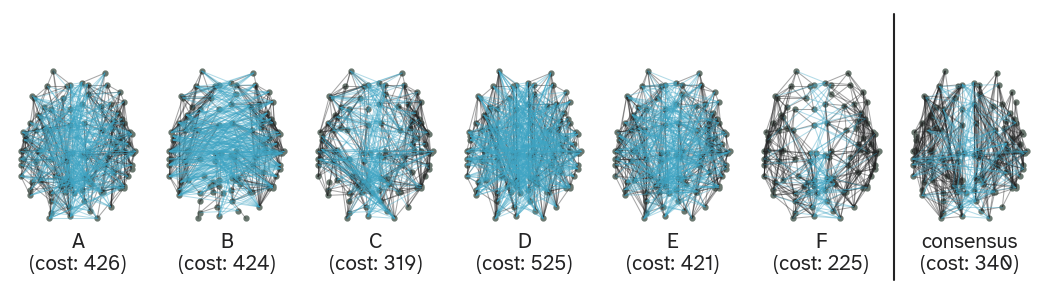

In [11]:
fig, axes = plt.subplot_mosaic(
    [["A", "B", "C", "D", "E", "F", "consensus"]], 
    figsize=(viz.cm_to_inch((18, 5))), dpi=150
)

# Plot connectomes
for idx, ax_label in enumerate(["A", "B", "C", "D", "E", "F", "consensus"]):
    axes[ax_label].scatter(coords[:, 0], coords[:, 1], s=4)

    connectome = connectomes[idx] if idx < 6 else empirical_connectome
    num_nodes = connectome.shape[0]
    
    alpha_within = 0.4
    color_within = "#232324" # HALF BLACK #E84653" #b8b8b8" # gray"

    alpha_between = 0.4
    # color_between = "#E84653" # LECKER RED 
    color_between = "#3FA5C4" #44cfcf" # #394D73" # #0F14F7" # TEAL or so 
    # color_between = "#F58300" # ORANGE
    
    # FIRST: Plot within-hemisphere connections (left hemisphere)
    for i in range(num_nodes//2):
        for j in range(i+1, num_nodes//2):
            if connectome[i, j] > 0:  # Only if there's a connection
                axes[ax_label].plot([coords[i, 0], coords[j, 0]],
                                    [coords[i, 1], coords[j, 1]],
                                    color=color_within, alpha=alpha_within, linewidth=0.5)

    # FIRST: Plot within-hemisphere connections (right hemisphere)
    for i in range(num_nodes//2, num_nodes):
        for j in range(i+1, num_nodes):
            if connectome[i, j] > 0:  # Only if there's a connection
                axes[ax_label].plot([coords[i, 0], coords[j, 0]],
                                    [coords[i, 1], coords[j, 1]],
                                    color=color_within, alpha=alpha_within, linewidth=0.5)

    # THEN: Plot between-hemisphere connections
    for i in range(num_nodes//2):
        for j in range(num_nodes//2, num_nodes):
            if connectome[i, j] > 0:  # Only if there's a connection
                axes[ax_label].plot([coords[i, 0], coords[j, 0]],
                                    [coords[i, 1], coords[j, 1]],
                                    color=color_between, alpha=alpha_between, linewidth=0.5)

    axes[ax_label].axis('equal')
    # axes[ax_label].set_title(ax_label + f"\n(cost: {int(np.round(np.sum(connectome * distance_matrix)/200, 2))})")
    axes[ax_label].axis('off')
    
    for spine in axes[ax_label].spines.values():
        spine.set_visible(False)
        
    axes[ax_label].set_xticks([])
    axes[ax_label].set_yticks([])
    
    axes[ax_label].set_title(ax_label + f"\n(cost: {int(np.round(np.sum(connectome * distance_matrix)/200, 2))})", y=-0.04)
    # plt.title('Scatter plot pythonspot.com', y=-0.01)
    
    # if ax_label == "F":
    #     axes[ax_label].spines['right'].set_visible(True)
    #     axes[ax_label].spines['right'].set_linewidth(1.5)

# TODO: Draw a line between F and consensus
# fig.add_artist(plt.Line2D([(axes["F"].get_position().x1 + axes["consensus"].get_position().x0) / 2 + 0.0525], 
#                           [0.05, 0.95], transform=fig.transFigure, color=color_within, linestyle="-", alpha=alpha_within, linewidth=0.5))

fig.add_artist(plt.Line2D([(axes["F"].get_position().x1 + axes["consensus"].get_position().x0) / 2 + 0.0525], 
                          [0.05, 0.95], transform=fig.transFigure, color=color_within, linestyle="-", 
                        #   alpha=alpha_within, 
                          linewidth=1))

plt.tight_layout()

plt.savefig(save_dir / f"figure_1_indiv_brains_{experiment_name}.pdf", bbox_inches="tight")

In [12]:
# Create a binary colorbar with these two colors, and plot it
color_within = "#232324" 
color_between = "#3FA5C4"



/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/landscape_and_six_example_gen_connectomes/figure_1_colorbar_within_between_105_distance_metrics_mst_animal_0.pdf


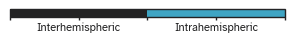

In [13]:
# Create and plot a binary colorbar using the specified colors
import matplotlib.pyplot as plt
import matplotlib as mpl

# Given colors
color_within = "#232324"
color_between = "#3FA5C4"

# Create a listed colormap
cmap = mpl.colors.ListedColormap([color_within, color_between])
bounds = [0, 1, 2]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# Create figure
fig, ax = plt.subplots(figsize=viz.cm_to_inch((9, 1)))

# Create a dummy ScalarMappable for the colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add colorbar
cbar = plt.colorbar(sm, cax=ax, orientation="horizontal", ticks=[0.5, 1.5])

# set the height of the colorbar to be 0.3 cm
cbar.ax.set_aspect(0.03)


cbar.ax.set_xticklabels(["Interhemispheric", "Intrahemispheric"])
plt.savefig(save_dir / f"figure_1_colorbar_within_between_{experiment_name}.pdf", bbox_inches="tight")
print(save_dir / f"figure_1_colorbar_within_between_{experiment_name}.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/landscape_and_six_example_gen_connectomes/figure_1_indiv_brains_105_distance_metrics_mst_animal_0_distance_coded.pdf


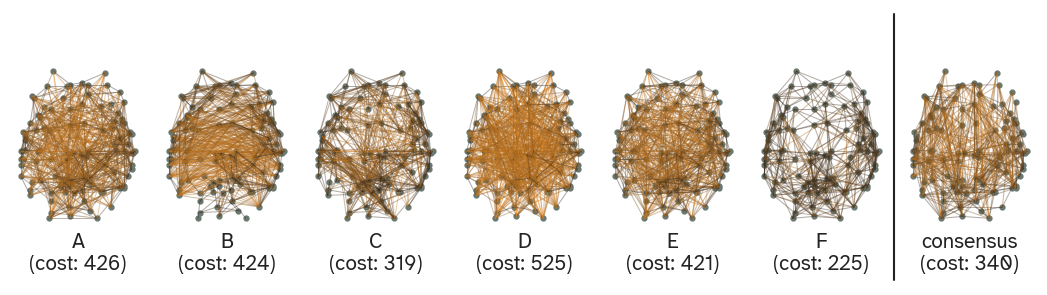

In [14]:
fig, axes = plt.subplot_mosaic(
    [["A", "B", "C", "D", "E", "F", "consensus"]], 
    figsize=(viz.cm_to_inch((18, 5))), dpi=150
)

# Parameters for distance-based coloring
short_color = "#232324"  # Black
# long_color = "#3FA5C4"   # Blue
long_color = "#FF961F" # "#F58300" # ORANGE
min_dist = np.min(distance_matrix[np.triu_indices_from(distance_matrix, k=1)])
max_dist = np.max(distance_matrix[np.triu_indices_from(distance_matrix, k=1)])

def map_color(dist):
    """Linearly interpolate between short_color and long_color based on distance"""
    t = (dist - min_dist) / (max_dist - min_dist)
    # Simple linear blend in RGB space
    short_rgb = np.array(mpl.colors.to_rgb(short_color)) # / 225 # [35, 35, 36]) / 255
    long_rgb = np.array(mpl.colors.to_rgb(long_color)) # / 225 # [63, 165, 196]) / 255
    rgb = (1 - t) * short_rgb + t * long_rgb
    return rgb

# Plot connectomes
for idx, ax_label in enumerate(["A", "B", "C", "D", "E", "F", "consensus"]):
    axes[ax_label].scatter(coords[:, 0], coords[:, 1], s=4)

    connectome = connectomes[idx] if idx < 6 else empirical_connectome
    num_nodes = connectome.shape[0]
    
    for i in range(num_nodes):
        for j in range(i+1, num_nodes):
            if connectome[i, j] > 0:
                dist = distance_matrix[i, j]
                color_rgb = map_color(dist)
                axes[ax_label].plot([coords[i, 0], coords[j, 0]],
                                    [coords[i, 1], coords[j, 1]],
                                    color=color_rgb, alpha=0.4, linewidth=0.5)

    axes[ax_label].axis('equal')
    axes[ax_label].axis('off')
    
    for spine in axes[ax_label].spines.values():
        spine.set_visible(False)
        
    axes[ax_label].set_xticks([])
    axes[ax_label].set_yticks([])
    
    axes[ax_label].set_title(ax_label + f"\n(cost: {int(np.round(np.sum(connectome * distance_matrix)/200, 2))})", y=-0.04)

# Draw a line between F and consensus if needed
fig.add_artist(plt.Line2D([(axes["F"].get_position().x1 + axes["consensus"].get_position().x0) / 2 + 0.0525], 
                          [0.05, 0.95], transform=fig.transFigure, color=short_color, linestyle="-", linewidth=1))

plt.tight_layout()

plt.savefig(save_dir / f"figure_1_indiv_brains_{experiment_name}_distance_coded.pdf", bbox_inches="tight")
print(save_dir / f"figure_1_indiv_brains_{experiment_name}_distance_coded.pdf")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/landscape_and_six_example_gen_connectomes/figure_1_colorbar_length_105_distance_metrics_mst_animal_0.pdf


<Figure size 354.331x39.3701 with 0 Axes>

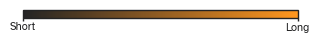

In [15]:
# Continuous colorbar from short_color to long_color
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, Normalize


# Create continuous colormap
cmap = LinearSegmentedColormap.from_list(
    "distance_cmap",
    [short_color, long_color]
)

# Continuous normalization
norm = Normalize(vmin=0.0, vmax=1.0)

# Create figure
fig = plt.figure(figsize=viz.cm_to_inch((9, 1)))

# Dummy ScalarMappable
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])


# Create a listed colormap
# cmap = mpl.colors.ListedColormap([short_color, long_color])

# Now continous colormap from short_color to long_color
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("distance_cmap", [short_color, long_color])


# Create figure
fig, ax = plt.subplots(figsize=viz.cm_to_inch((9, 1)))

# Create a dummy ScalarMappable for the colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add colorbar
cbar = plt.colorbar(sm, cax=ax, orientation="horizontal", ticks=[0, 1])

# set the height of the colorbar to be 0.3 cm
cbar.ax.set_aspect(0.03)


cbar.ax.set_xticklabels(["Short", "Long"])
plt.savefig(save_dir / f"figure_1_colorbar_length_{experiment_name}.pdf", bbox_inches="tight")
print(save_dir / f"figure_1_colorbar_length_{experiment_name}.pdf")
plt.show()

In [16]:
# fig, axes = plt.subplot_mosaic(
#     [["A", "B", "C", "D", "E", "F", "consensus"]], 
#     figsize=(viz.cm_to_inch((18, 5))), dpi=150
# )

# # Plot connectomes
# for idx, ax_label in enumerate(["A", "B", "C", "D", "E", "F", "consensus"]):
#     axes[ax_label].scatter(coords[:, 0], coords[:, 1], s=4)

#     connectome = connectomes[idx] if idx < 6 else empirical_connectome
#     num_nodes = connectome.shape[0]
    
#     alpha_within = 0.4
#     color_within = "#232324" # HALF BLACK #E84653" #b8b8b8" # gray"

#     alpha_between = 0.4
#     # color_between = "#E84653" # LECKER RED 
#     color_between = "#3FA5C4" #44cfcf" # #394D73" # #0F14F7" # TEAL or so 
    
#     # FIRST: Plot within-hemisphere connections (left hemisphere)
#     for i in range(num_nodes//2):
#         for j in range(i+1, num_nodes//2):
#             if connectome[i, j] > 0:  # Only if there's a connection
#                 axes[ax_label].plot([coords[i, 0], coords[j, 0]],
#                                     [coords[i, 1], coords[j, 1]],
#                                     color=color_within, alpha=alpha_within, linewidth=0.5)

#     # FIRST: Plot within-hemisphere connections (right hemisphere)
#     for i in range(num_nodes//2, num_nodes):
#         for j in range(i+1, num_nodes):
#             if connectome[i, j] > 0:  # Only if there's a connection
#                 axes[ax_label].plot([coords[i, 0], coords[j, 0]],
#                                     [coords[i, 1], coords[j, 1]],
#                                     color=color_within, alpha=alpha_within, linewidth=0.5)

#     # THEN: Plot between-hemisphere connections
#     for i in range(num_nodes//2):
#         for j in range(num_nodes//2, num_nodes):
#             if connectome[i, j] > 0:  # Only if there's a connection
#                 axes[ax_label].plot([coords[i, 0], coords[j, 0]],
#                                     [coords[i, 1], coords[j, 1]],
#                                     color=color_between, alpha=alpha_between, linewidth=0.5)

#     axes[ax_label].axis('equal')
#     # axes[ax_label].set_title(ax_label + f"\n(cost: {int(np.round(np.sum(connectome * distance_matrix)/200, 2))})")
#     axes[ax_label].axis('off')
    
#     for spine in axes[ax_label].spines.values():
#         spine.set_visible(False)
        
#     axes[ax_label].set_xticks([])
#     axes[ax_label].set_yticks([])
    
#     axes[ax_label].set_title(ax_label + f"\n(cost: {int(np.round(np.sum(connectome * distance_matrix)/200, 2))})", y=-0.04)
#     # plt.title('Scatter plot pythonspot.com', y=-0.01)
    
#     # if ax_label == "F":
#     #     axes[ax_label].spines['right'].set_visible(True)
#     #     axes[ax_label].spines['right'].set_linewidth(1.5)

# # TODO: Draw a line between F and consensus
# # fig.add_artist(plt.Line2D([(axes["F"].get_position().x1 + axes["consensus"].get_position().x0) / 2 + 0.0525], 
# #                           [0.05, 0.95], transform=fig.transFigure, color=color_within, linestyle="-", alpha=alpha_within, linewidth=0.5))

# fig.add_artist(plt.Line2D([(axes["F"].get_position().x1 + axes["consensus"].get_position().x0) / 2 + 0.0525], 
#                           [0.05, 0.95], transform=fig.transFigure, color=color_within, linestyle="-", 
#                         #   alpha=alpha_within, 
#                           linewidth=1))

# plt.tight_layout()

# # plt.savefig(save_dir / f"figure_1_indiv_brains_{experiment_name}.pdf", bbox_inches="tight")

In [17]:
# axes[ax_label].spines["right"].set_visible(True)

# MST 

(-64.0, 68.0, -101.7, 67.7)

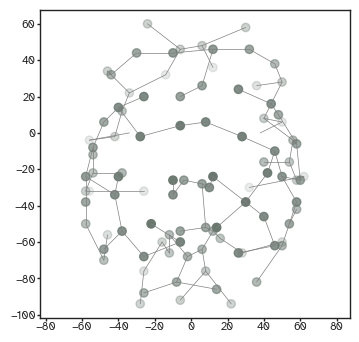

In [18]:
coords_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/hcp_schaefer_100/Schaefer_100_MNI_coords.txt"
coords = np.loadtxt(coords_file)[:, :3]
# coords

alpha_values = (coords[:, 2] - np.min(coords[:, 2])) / (np.max(coords[:, 2]) - np.min(coords[:, 2]))
plt.figure(figsize=(4,4))
plt.scatter(coords[:, 0], coords[:, 1], alpha=alpha_values) # 0: Left-right, 1: Anterior-posterior, 2: Inferior-superior

# Add MST seed 
seed = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/seeds/mst_schaeffer.npy")[0]
num_nodes = seed.shape[0]
for i in range(num_nodes):
    for j in range(i+1, num_nodes):
        if seed[i, j] > 0:
            plt.plot([coords[i, 0], coords[j, 0]], 
                     [coords[i, 1], coords[j, 1]], 
                     color='gray', alpha=1, linewidth=0.5)
plt.axis('equal')


Loading brain surface...
Aligning brain surface...


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


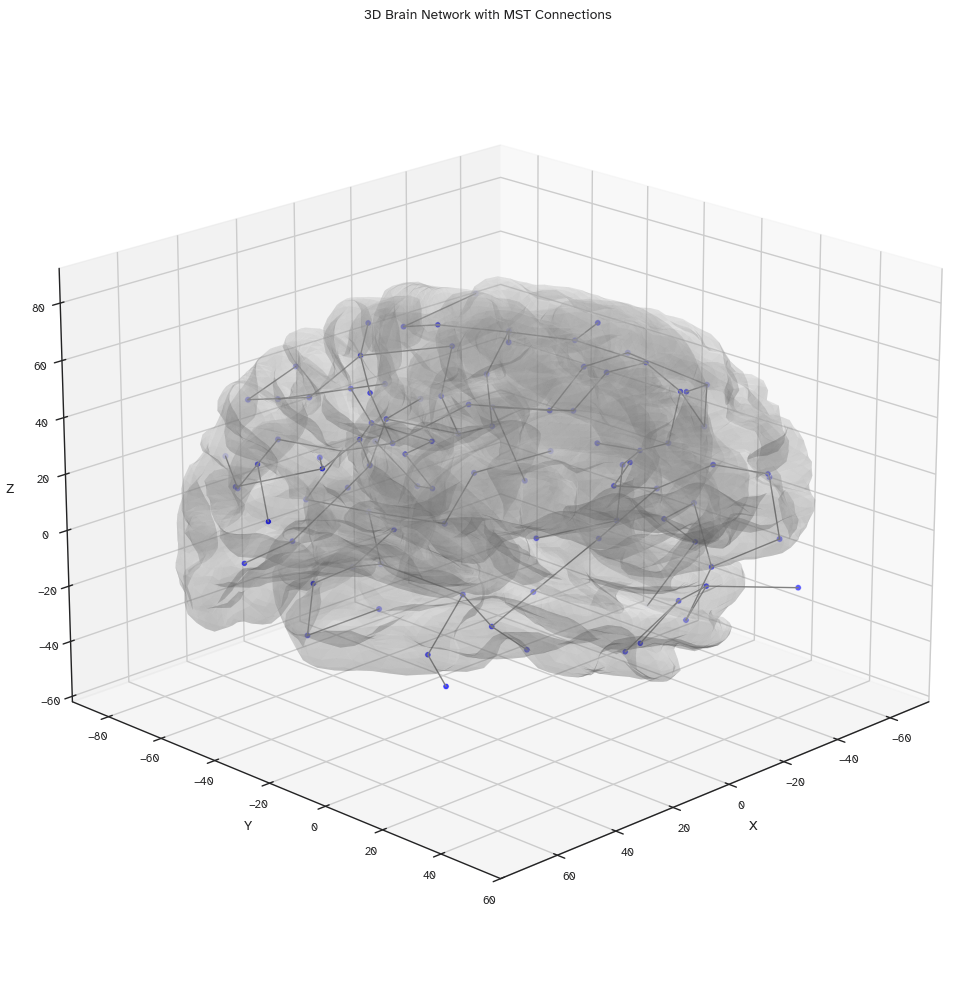

Visualization complete!


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from nilearn import datasets
from nilearn.surface import load_surf_mesh

# Load your coordinates
coords_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/hcp_schaefer_100/Schaefer_100_MNI_coords.txt"
coords = np.loadtxt(coords_file)[:, :3]

# Load your MST seed
seed = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/seeds/mst_schaeffer.npy")[0]
num_nodes = seed.shape[0]

# Load brain surface
print("Loading brain surface...")
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
lh_coords, lh_faces = load_surf_mesh(fsaverage['pial_left'])
rh_coords, rh_faces = load_surf_mesh(fsaverage['pial_right'])

# Combine hemispheres
rh_faces_offset = rh_faces + len(lh_coords)
brain_coords = np.vstack([lh_coords, rh_coords])
brain_faces = np.vstack([lh_faces, rh_faces_offset])

# Align brain to your node coordinates
print("Aligning brain surface...")
corrected_coords = brain_coords.copy()
corrected_coords[:, [0, 1, 2]] = corrected_coords[:, [1, 0, 2]]
corrected_coords[:, 0] *= -1

node_center = coords.mean(axis=0)
brain_center = corrected_coords.mean(axis=0)
aligned_brain_coords = corrected_coords - brain_center + node_center

# Create figure
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot brain surface (translucent)
ax.plot_trisurf(aligned_brain_coords[:, 0], 
                aligned_brain_coords[:, 1], 
                aligned_brain_coords[:, 2],
                triangles=brain_faces,
                color='lightgray',
                alpha=0.2,
                linewidth=0,
                antialiased=True)

# Plot connections from MST seed
for i in range(num_nodes):
    for j in range(i+1, num_nodes):
        if seed[i, j] > 0:
            ax.plot([coords[i, 0], coords[j, 0]], 
                   [coords[i, 1], coords[j, 1]], 
                   [coords[i, 2], coords[j, 2]],
                   color='gray', alpha=1, linewidth=1) # 0.5)

# Plot nodes with depth-based alpha
alpha_values = (coords[:, 2] - np.min(coords[:, 2])) / (np.max(coords[:, 2]) - np.min(coords[:, 2]))
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], 
          c='blue', s=20, alpha=alpha_values, edgecolors='white', linewidth=0.5)

# Set viewing angle and labels
ax.view_init(elev=20, azim=45)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Brain Network with MST Connections')

# Equal aspect ratio
max_range = np.array([coords[:, 0].max()-coords[:, 0].min(),
                      coords[:, 1].max()-coords[:, 1].min(),
                      coords[:, 2].max()-coords[:, 2].min()]).max() / 2.0
mid_x = (coords[:, 0].max()+coords[:, 0].min()) * 0.5
mid_y = (coords[:, 1].max()+coords[:, 1].min()) * 0.5
mid_z = (coords[:, 2].max()+coords[:, 2].min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.tight_layout()
plt.show()

print("Visualization complete!")

# Empirical connectomes 

In [20]:
empirical_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data/01_connectomes/00_connectomes_density10.npy")
empirical_connectome = empirical_connectomes[0] # the consensus! Had shape (1,100,100) before. 

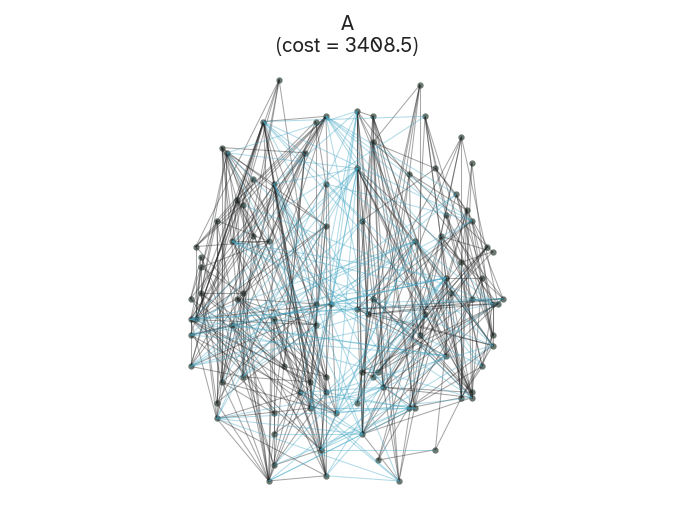

In [21]:
fig, axes = plt.subplot_mosaic(
    [["A"]], 
    figsize=(viz.cm_to_inch((12, 9))), dpi=150
)

# Plot connectomes
for idx, ax_label in enumerate(["A"]):
    axes[ax_label].scatter(coords[:, 0], coords[:, 1], s=4)
    
    connectome = empirical_connectome
    num_nodes = connectome.shape[0]
    
    alpha_within = 0.4
    color_within = "#232324" # HALF BLACK #E84653" #b8b8b8" # gray"

    alpha_between = 0.4
    # color_between = "#E84653" # LECKER RED 
    color_between = "#3FA5C4" #44cfcf" # #394D73" # #0F14F7" # TEAL or so 
    
    # FIRST: Plot within-hemisphere connections (left hemisphere)
    for i in range(num_nodes//2):
        for j in range(i+1, num_nodes//2):
            if connectome[i, j] > 0:  # Only if there's a connection
                axes[ax_label].plot([coords[i, 0], coords[j, 0]],
                                    [coords[i, 1], coords[j, 1]],
                                    color=color_within, alpha=alpha_within, linewidth=0.5)

    # FIRST: Plot within-hemisphere connections (right hemisphere)
    for i in range(num_nodes//2, num_nodes):
        for j in range(i+1, num_nodes):
            if connectome[i, j] > 0:  # Only if there's a connection
                axes[ax_label].plot([coords[i, 0], coords[j, 0]],
                                    [coords[i, 1], coords[j, 1]],
                                    color=color_within, alpha=alpha_within, linewidth=0.5)

    # THEN: Plot between-hemisphere connections
    for i in range(num_nodes//2):
        for j in range(num_nodes//2, num_nodes):
            if connectome[i, j] > 0:  # Only if there's a connection
                axes[ax_label].plot([coords[i, 0], coords[j, 0]],
                                    [coords[i, 1], coords[j, 1]],
                                    color=color_between, alpha=alpha_between, linewidth=0.5)

    axes[ax_label].axis('equal')
    axes[ax_label].set_title(ax_label + f"\n(cost = {np.round(np.sum(connectome * distance_matrix)/20, 1)})")
    axes[ax_label].axis('off')
    
    for spine in axes[ax_label].spines.values():
        spine.set_visible(False)
    axes[ax_label].set_xticks([])
    axes[ax_label].set_yticks([])
    
plt.tight_layout()